# Santer & Poterjoy 2026 Likelihood Estimation LPF Experiments


In [131]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood

reload(dap)

np.set_printoptions(suppress=True)


In [132]:
poep = {'mu': 0, 'sigma': 2.0} 
poep_gaus_lg = {'mu': 0, 'sigma': 1.8} 
poep_gaus_cauchy = {'mu': 0, 'sigma': 0.5} 
# original experiments were gamma = 0.2!
uoep_cauchy = {'x0': 0, 'gamma': 0.34}
poep_cauchy = {'x0': 0, 'gamma': 0.34} 

uoep_logistic = {'x0': 0, 'scale' : 1}
poep_logistic = {'x0': 0, 'scale' : 1} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [133]:
e_name = 'L05: Cauchy'
print(f'starting experiment {e_name}')
bw = 0.02
knn = 0.1
# original experiments!
#bw = 0.02
#knn = 0.1
klb=0.0
e_sd_kecd = dap.Expt(e_name, {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 0,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': poep,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'Ne':80,
                       'T': 501,
                       'T_train': 500,
                       'nle_type': 4,
                       'nle_every': 50, 
                       'Neig': 50,
                       'knn_frac': knn,
                       'bw_dm': bw,
                       'klb':klb,
                       'debug_nle_noDA': False})


starting experiment L05: Cauchy


In [134]:
dap.runDA(e_sd_kecd)
print('starting e sd gaus')
dap.plot_pab(e_sd_kecd)

DB: Starting cycle 0
DB: Starting cycle 100
DB: Starting cycle 200
DB: Starting cycle 300
DB: Starting cycle 400
DB: Starting cycle 500
largest distance is 1.6501793126380544
(array([-0.65017931, -0.63850092, -0.62606509, ...,  0.97179931,
        0.98520936,  1.        ]), array([1, 1, 1, ..., 1, 1, 1]))
after nearest
359940000
largest distance is now 0.53026143169838
mean distance is now 0.0030144364085875662
median distance is now 0.0
median distance without 0s: 0.02319870347222309
180347516
largest distance is 1.7133672285614066
(array([-0.71336723, -0.64642246, -0.63128044, ...,  0.98241992,
        0.98498857,  1.        ]), array([1, 1, 1, ..., 1, 1, 1]))
after nearest
359940000
largest distance is now 0.5651363157674105
mean distance is now 0.0029442879846468947
median distance is now 0.0
median distance without 0s: 0.02176350300071379
180323584
starting e sd gaus


largest distance is 1.4847449881864874
(array([-0.48474499, -0.48306935, -0.47496005, ...,  0.9460392 ,
        0.99397838,  1.        ]), array([1, 1, 1, ..., 1, 1, 1]))
after nearest
8997000
largest distance is now 1.4847449881864874
mean distance is now 0.3215243725950577
median distance is now 0.2772886845902648
median distance without 0s: 0.27739248576538916
4498500
largest distance is 1.5533921470702898
(array([-0.55339215, -0.52420474, -0.50451147, ...,  0.8481538 ,
        0.85493702,  1.        ]), array([1, 1, 1, ..., 1, 1, 1]))
after nearest
8997000
largest distance is now 1.5533921470702898
mean distance is now 0.27933581471547514
median distance is now 0.2392889474322299
median distance without 0s: 0.2393836371558337
4498500


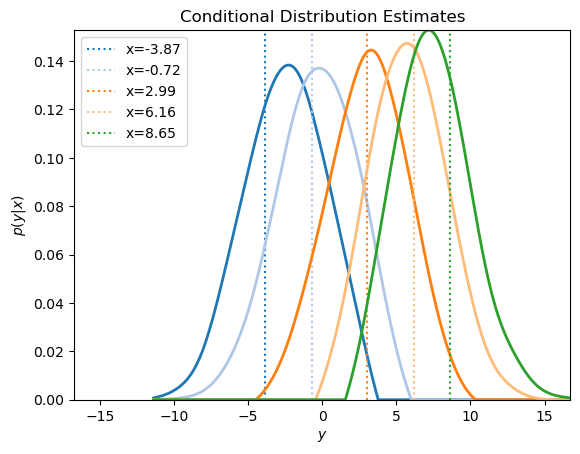

<Figure size 640x480 with 0 Axes>

In [130]:
#dap.plot_pab(e_sd_kecd, plot_states=True)
data = np.load('rkhs_input.npz')
x_train, y_train = data['x_train'], data['y_train']


def plot_pab(knnf, bw, x_train, y_train, ax = None, plot_states=True, pab_sample_states=-999):
      if ax is None:
            fig, ax = plt.subplots(1, 1)

      knn = int(knnf * y_train.shape[1])
          
      pab = rkhs_likelihood(y_train.T, x_train.T, 50, knn, 0.0,  bw, 1, 1.0)[0]
      ys = np.sort(y_train[0, :])
      ind2 = np.argsort(y_train[0, :])
      diff = np.diff(ys)
      fig = plt.figure(31)
      plt.clf()
      cmap = plt.get_cmap('tab20')
      htp = []
      if pab_sample_states == -999:
            states = np.quantile(x_train, [0.1, 0.25, 0.5, 0.75, 0.9])
      else:
            states = pab_sample_states
      for ind, j in enumerate(states):
            dum = np.abs(j - x_train[0, :])
            ind1 = np.argsort(dum)[0]
            h = pab[ind2, ind1]
            # Normalize for plotting
            normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
            h_norm = h / normalization
            htp.append(h_norm)
            # Plotting
            ax.plot(ys, h_norm, linewidth=2, color=cmap(ind))
            if plot_states:
                  ax.axvline(x=j, color=cmap(ind), linestyle='dotted', label=f'x={j:.2f}')
      bound = max(np.abs(np.min(x_train)), np.abs(np.max(x_train)))
      ax.set_xlim([-bound, bound])
      ax.set_ylim([0, np.max(htp)])
      ax.legend()
      ax.set_title(f'Conditional Distribution Estimates')
      ax.set_xlabel('$y$')
      ax.set_ylabel('$p(y | x)$')
      if ax is None:
            return fig, ax
      else:
            return ax

#for knnf in (0.05, 0.1, 0.15, 0.2, 0.25, 0.3):
for knnf in (1.0,):
    fig, ax = plt.subplots()
    plot_pab(knnf, 0.02, x_train, y_train, ax=ax)
    plt.show(fig)


In [116]:
sd = np.load('scaled_data.npy')

In [117]:
np.unique(sd, return_counts=True)[1]

array([1, 1, 1, ..., 1, 1, 1])

In [118]:
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.neighbors import NearestNeighbors

knn = int(0.1 * len(sd))
sknn = NearestNeighbors(n_neighbors=knn, n_jobs=-1, algorithm='ball_tree')
sknn.fit(sd)
dists = sknn.kneighbors_graph(sd, mode='distance')
conn = sknn.kneighbors_graph(sd, mode='connectivity')


In [119]:
arr = dists.toarray()
upper = arr[np.triu_indices_from(arr, k=1)]
    
np.median(upper[upper!=0])

np.float64(0.022228910528891102)

In [120]:
from scipy.sparse.csgraph import connected_components
conn

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 900000 stored elements and shape (3000, 3000)>

In [121]:
n_comp, labels = connected_components(conn)
n_comp

1

In [107]:
from ipywidgets import *
def plot_adjacency_knn(knn_val):    
    sknn = NearestNeighbors(n_neighbors=knn_val, n_jobs=-1, algorithm='ball_tree')
    sknn.fit(sd)
    # dists = sknn.kneighbors_graph(sd, mode='distance')
    conn = sknn.kneighbors_graph(sd, mode='connectivity')
    plt.imshow(conn.toarray())

    
interact(
    plot_adjacency_knn,
    knn_val=IntSlider(min=1, max=3000, step=10, value=1))

interactive(children=(IntSlider(value=1, description='knn_val', max=3000, min=1, step=10), Output()), _dom_cla…

<function __main__.plot_adjacency_knn(knn_val)>

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment L05: Cauchy'}, xlabel='$y$', ylabel='$p(y | x)$'>

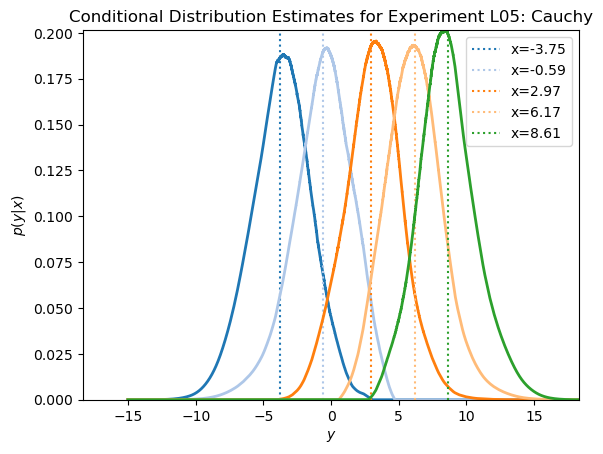

<Figure size 640x480 with 0 Axes>

In [139]:
dap.plot_pab(e_sd_kecd, plot_states=True)